In [4]:
import pandas as pd
import numpy as np
df = pd.read_excel("../data/Online Retail.xlsx")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head())

Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
# Create a copy for cleaning
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove cancelled invoices
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Keep only positive quantities
df_clean = df_clean[df_clean['Quantity'] > 0]

# Keep only positive prices
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Remove rows with missing customer IDs
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove rows with missing descriptions
df_clean = df_clean.dropna(subset=['Description'])

# Reset index
df_clean = df_clean.reset_index(drop=True)

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))
print("Missing CustomerID:", df_clean['CustomerID'].isna().sum())

Original rows: 541909
Cleaned rows: 392692
Rows removed: 149217
Missing CustomerID: 0


In [7]:
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Total Sales: £", round(df_clean['TotalAmount'].sum(), 2))
print("Average Transaction Value: £", round(df_clean['TotalAmount'].mean(), 2))
print("Minimum Transaction Value: £", round(df_clean['TotalAmount'].min(), 2))
print("Maximum Transaction Value: £", round(df_clean['TotalAmount'].max(), 2))

Total Sales: £ 8887208.89
Average Transaction Value: £ 22.63
Minimum Transaction Value: £ 0.0
Maximum Transaction Value: £ 168469.6


In [8]:
# Set the reference date as one day after the last transaction
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics for each customer
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Display first 5 customers
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [9]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


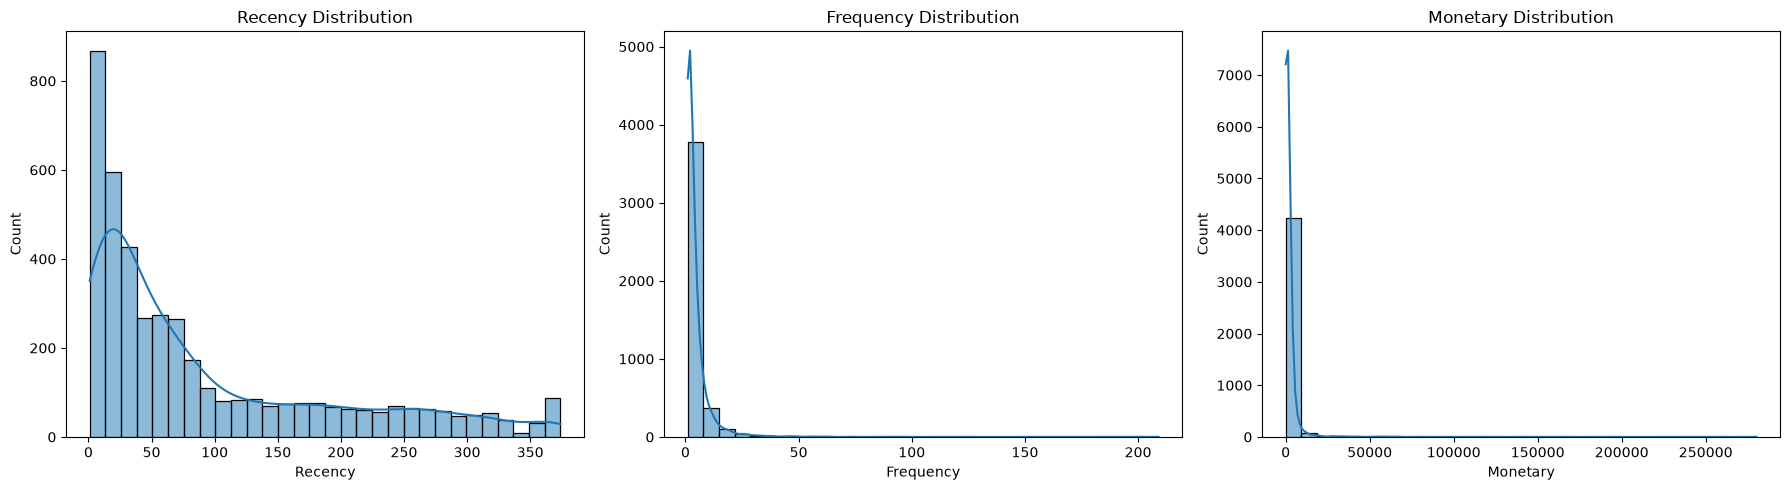

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [11]:
# Apply log transformation to reduce the effect of extreme values
rfm_log = np.log1p(rfm)

print("Original RFM:")
display(rfm.head())

print("\nLog-transformed RFM:")
display(rfm_log.head())

Original RFM:


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40



Log-transformed RFM:


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    index=rfm_log.index,
    columns=rfm_log.columns
)

print("Scaled RFM:")
display(rfm_scaled.head())

print("\nMean after scaling:")
print(rfm_scaled.mean())

print("\nStandard deviation after scaling:")
print(rfm_scaled.std())

Scaled RFM:


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.461993,-0.955214,3.707716
12347.0,-2.038734,1.074425,1.414903
12348.0,0.373104,0.386304,0.720024
12349.0,-0.623086,-0.955214,0.702287
12350.0,1.424558,-0.955214,-0.614514



Mean after scaling:
Recency     -8.025955e-17
Frequency   -8.189750e-18
Monetary    -3.669008e-16
dtype: float64

Standard deviation after scaling:
Recency      1.000115
Frequency    1.000115
Monetary     1.000115
dtype: float64


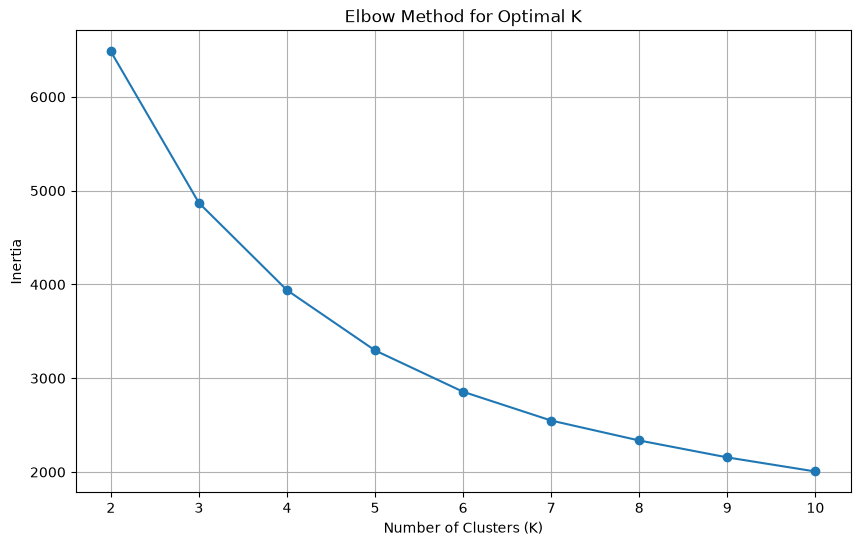

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [14]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores[k] = score

print("Silhouette Scores:")

for k, score in silhouette_scores.items():
    print(f"K = {k}: {score:.4f}")

Silhouette Scores:
K = 2: 0.4328
K = 3: 0.3365
K = 4: 0.3375
K = 5: 0.3162
K = 6: 0.3124
K = 7: 0.3092
K = 8: 0.3033
K = 9: 0.2811
K = 10: 0.2767


In [15]:
# Final K-Means model with 4 customer segments
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Clustering completed successfully!")
print("\nNumber of customers in each cluster:")
print(rfm['Cluster'].value_counts().sort_index())

Clustering completed successfully!

Number of customers in each cluster:
Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


In [16]:
# Calculate average RFM values for each cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

# Add number of customers in each cluster
cluster_profile['Customer_Count'] = rfm['Cluster'].value_counts().sort_index()

# Display cluster profile
cluster_profile

,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,12.17,13.75,8088.02,713
1,181.51,1.32,341.00,1622
2,17.70,2.19,557.32,837
3,71.64,4.08,1801.78,1166


In [17]:
# Assign meaningful names to the customer segments
cluster_names = {
    0: 'High-Value Customers',
    1: 'Inactive / Low-Value Customers',
    2: 'Recent Low-Frequency Customers',
    3: 'Regular / Valuable Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

# Display segment distribution
segment_summary = (
    rfm['Segment']
    .value_counts()
    .rename_axis('Segment')
    .reset_index(name='Customer_Count')
)

segment_summary

,Segment,Customer_Count
0,Inactive / Low-Value Customers,1622
1,Regular / Valuable Customers,1166
2,Recent Low-Frequency Customers,837
3,High-Value Customers,713


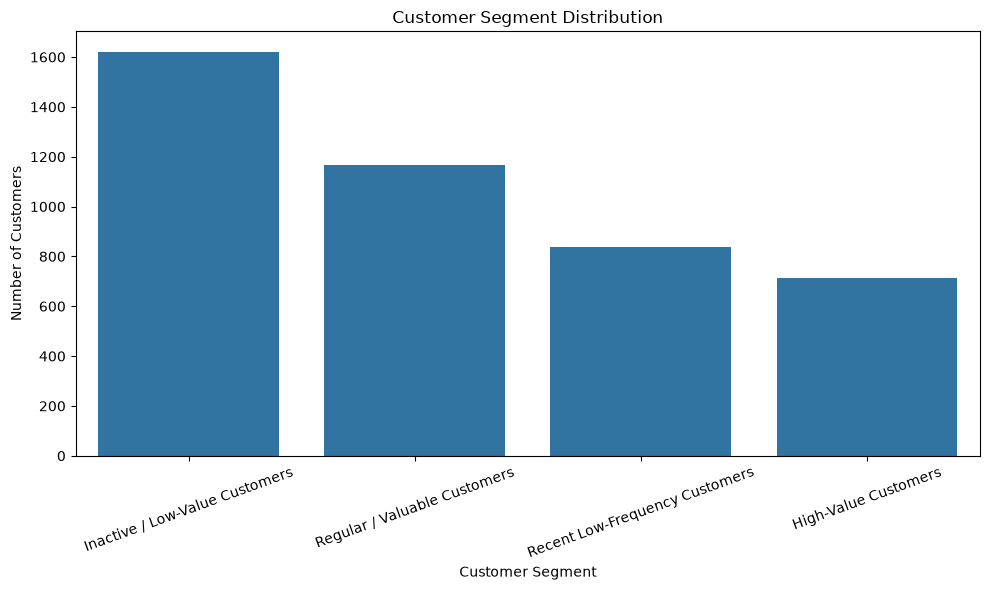

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_summary,
    x='Segment',
    y='Customer_Count'
)

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [19]:
# Calculate average RFM values for each segment
segment_rfm = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

segment_rfm

,Recency,Frequency,Monetary
Segment,,,
High-Value Customers,12.17,13.75,8088.02
Inactive / Low-Value Customers,181.51,1.32,341.00
Recent Low-Frequency Customers,17.70,2.19,557.32
Regular / Valuable Customers,71.64,4.08,1801.78


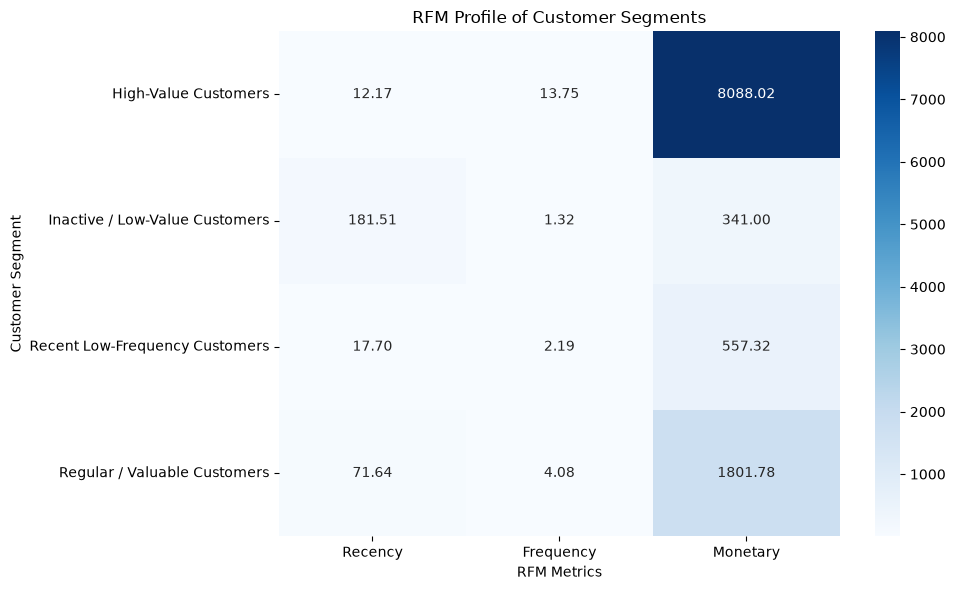

In [20]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    segment_rfm,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('RFM Profile of Customer Segments')
plt.xlabel('RFM Metrics')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

## Business Insights and Customer Strategies

### 1. High-Value Customers
- These customers purchase frequently and spend significantly more.
- Focus on loyalty programs and exclusive offers.
- Provide personalized recommendations and early access to new products.
- Aim to retain these customers and increase their lifetime value.

### 2. Inactive / Low-Value Customers
- These customers have not purchased recently and have relatively low spending.
- Use re-engagement campaigns, limited-time discounts, and reminder emails.
- Analyze previous purchases to create relevant offers.
- The goal is to encourage repeat purchases.

### 3. Recent Low-Frequency Customers
- These customers have purchased recently but have relatively low purchase frequency.
- Encourage a second or repeat purchase using personalized product suggestions.
- Use cross-selling and bundle offers based on recent purchases.
- The goal is to convert them into regular customers.

### 4. Regular / Valuable Customers
- These customers purchase more regularly and generate meaningful revenue.
- Use loyalty rewards and personalized promotions.
- Encourage higher-value purchases through cross-selling and upselling.
- The goal is to strengthen their relationship with the business.

In [21]:
# Calculate customer percentage for each segment
segment_summary['Percentage'] = (
    segment_summary['Customer_Count'] / len(rfm) * 100
).round(2)

segment_summary

,Segment,Customer_Count,Percentage
0,Inactive / Low-Value Customers,1622,37.39
1,Regular / Valuable Customers,1166,26.88
2,Recent Low-Frequency Customers,837,19.29
3,High-Value Customers,713,16.44


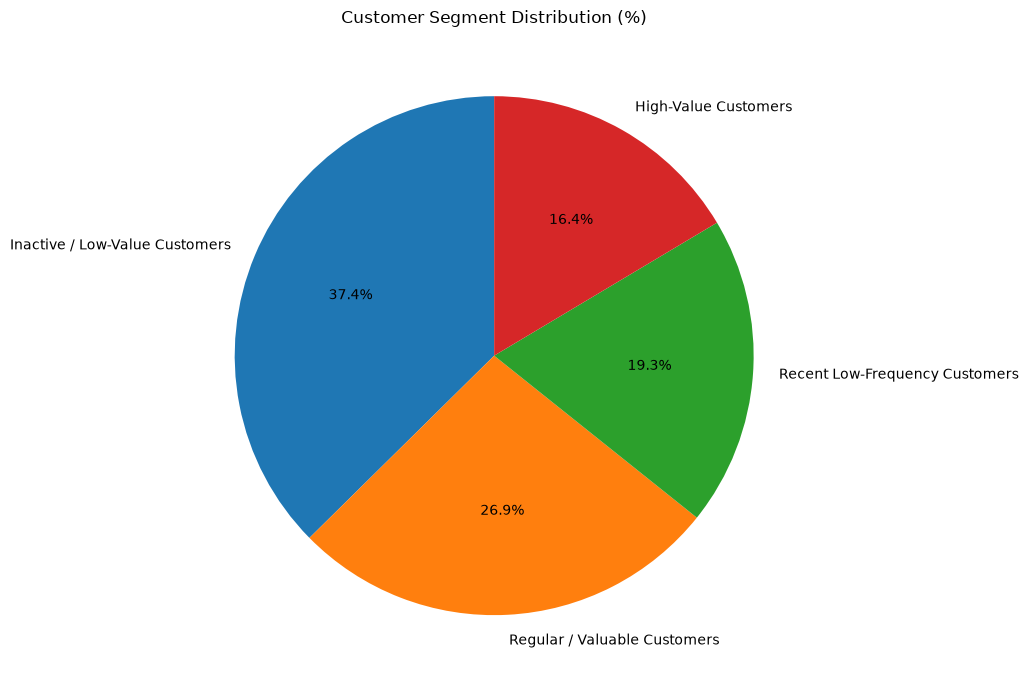

In [22]:
plt.figure(figsize=(9, 7))

plt.pie(
    segment_summary['Customer_Count'],
    labels=segment_summary['Segment'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Segment Distribution (%)')
plt.tight_layout()
plt.show()

In [23]:
# Create final customer segmentation dataset
customer_segments = rfm.reset_index()

# Keep useful columns in a clean order
customer_segments = customer_segments[
    ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']
]

print("Final dataset shape:", customer_segments.shape)
display(customer_segments.head())

Final dataset shape: (4338, 6)


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,Regular / Valuable Customers
1,12347.0,2,7,4310.00,0,High-Value Customers
2,12348.0,75,4,1797.24,3,Regular / Valuable Customers
3,12349.0,19,1,1757.55,2,Recent Low-Frequency Customers
4,12350.0,310,1,334.40,1,Inactive / Low-Value Customers


In [24]:
# Save final customer segmentation dataset
output_path = '../data/customer_segments.csv'

customer_segments.to_csv(output_path, index=False)

print(f"File saved successfully: {output_path}")

File saved successfully: ../data/customer_segments.csv


In [25]:
import os

print("File exists:", os.path.exists(output_path))
print("File size:", round(os.path.getsize(output_path) / 1024, 2), "KB")

File exists: True
File size: 227.3 KB


In [26]:
# Save segment-level summary
segment_rfm_final = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

segment_rfm_final['Customer_Count'] = rfm['Segment'].value_counts()

segment_rfm_final['Customer_Percentage'] = (
    segment_rfm_final['Customer_Count'] / len(rfm) * 100
).round(2)

segment_rfm_final = segment_rfm_final.reset_index()

segment_rfm_final.to_csv(
    '../data/segment_summary.csv',
    index=False
)

print("Segment summary saved successfully!")
display(segment_rfm_final)

Segment summary saved successfully!


,Segment,Recency,Frequency,Monetary,Customer_Count,Customer_Percentage
0,High-Value Customers,12.17,13.75,8088.02,713,16.44
1,Inactive / Low-Value Customers,181.51,1.32,341.00,1622,37.39
2,Recent Low-Frequency Customers,17.70,2.19,557.32,837,19.29
3,Regular / Valuable Customers,71.64,4.08,1801.78,1166,26.88
